In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor

import joblib

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

SEED = 42


In [2]:
url_housing = "https://storage.googleapis.com/dqlab-dataset/HousingData.csv"
data = pd.read_csv(url_housing)

print("Ukuran data:", data.shape)
display(data.head())
data.info()


Ukuran data: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [3]:
jumlah_duplikat = data.duplicated().sum()
print("Jumlah baris duplikat:", jumlah_duplikat)

missing = data.isna().sum().sort_values(ascending=False)
print("\nMissing value per kolom (yang > 0):")
print(missing[missing > 0])

display(data.describe().T)


Jumlah baris duplikat: 0

Missing value per kolom (yang > 0):
CRIM     20
ZN       20
INDUS    20
CHAS     20
LSTAT    20
AGE      20
dtype: int64


,count,mean,std,min,25%,50%,75%,max
CRIM,486.0,3.611874,8.720192,0.00632,0.081900,0.253715,3.560263,88.9762
ZN,486.0,11.211934,23.388876,0.00000,0.000000,0.000000,12.500000,100.0000
INDUS,486.0,11.083992,6.835896,0.46000,5.190000,9.690000,18.100000,27.7400
CHAS,486.0,0.069959,0.255340,0.00000,0.000000,0.000000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.538000,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.208500,6.623500,8.7800
AGE,486.0,68.518519,27.999513,2.90000,45.175000,76.800000,93.975000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.207450,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.000000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.000000,666.000000,711.0000


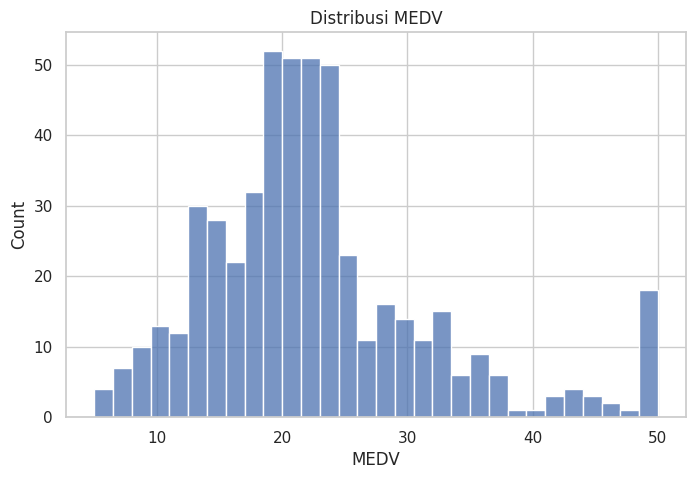

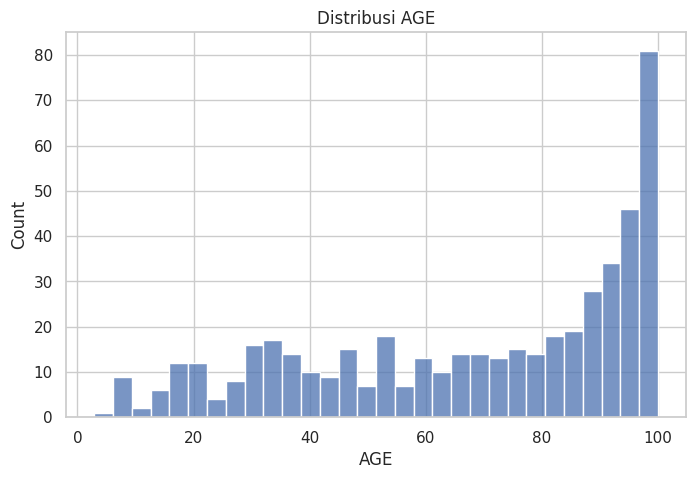

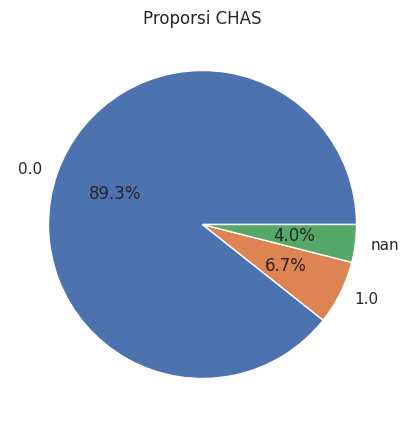

In [4]:
sns.histplot(data["MEDV"], bins=30)
plt.title("Distribusi MEDV")
plt.show()

sns.histplot(data["AGE"], bins=30)
plt.title("Distribusi AGE")
plt.show()

prop_chas = data["CHAS"].value_counts(dropna=False).sort_index()
plt.pie(prop_chas.values, labels=prop_chas.index, autopct="%1.1f%%")
plt.title("Proporsi CHAS")
plt.show()


In [5]:
fitur = data.drop(columns=["MEDV"])
target = data["MEDV"]

# holdout test 20%
fitur_latihval, fitur_uji, target_latihval, target_uji = train_test_split(
    fitur, target, test_size=0.2, random_state=SEED
)

# latih 64%, valid 16%, uji 20%
fitur_latih, fitur_valid, target_latih, target_valid = train_test_split(
    fitur_latihval, target_latihval, test_size=0.2, random_state=SEED
)

print("Latih :", fitur_latih.shape)
print("Valid :", fitur_valid.shape)
print("Uji   :", fitur_uji.shape)


Latih : (323, 13)
Valid : (81, 13)
Uji   : (102, 13)


In [6]:
def laporan_regresi(y_asli, y_pred, label=""):
    rmse = np.sqrt(mean_squared_error(y_asli, y_pred))
    mae = mean_absolute_error(y_asli, y_pred)
    r2 = r2_score(y_asli, y_pred)

    print(f"{label} RMSE: {rmse:.4f}")
    print(f"{label} MAE : {mae:.4f}")
    print(f"{label} R2  : {r2:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}


In [8]:
kolom_numerik = fitur.columns.tolist()

kolom_log = ["B", "CRIM"]
kolom_biasa = [k for k in kolom_numerik if k not in kolom_log]

transform_log = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

transform_biasa = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

pra_proses = ColumnTransformer(
    transformers=[
        ("log", transform_log, kolom_log),
        ("biasa", transform_biasa, kolom_biasa)
    ],
    remainder="drop"
)


In [9]:
model_baseline = Pipeline(steps=[
    ("pra_proses", pra_proses),
    ("model", DummyRegressor(strategy="mean"))
])

model_baseline.fit(fitur_latih, target_latih)
pred_valid_baseline = model_baseline.predict(fitur_valid)

print("Baseline (DummyRegressor) di Validasi:")
_ = laporan_regresi(target_valid, pred_valid_baseline, "Valid")


Baseline (DummyRegressor) di Validasi:
Valid RMSE: 8.4322
Valid MAE : 6.4148
Valid R2  : -0.0000


In [10]:
kandidat = {
    "Ridge": Ridge(random_state=SEED),
    "GBR": GradientBoostingRegressor(random_state=SEED),
}

hasil_validasi = []
pipeline_terlatih = {}

for nama, mdl in kandidat.items():
    pipa = Pipeline(steps=[
        ("pra_proses", pra_proses),
        ("model", mdl)
    ])

    pipa.fit(fitur_latih, target_latih)
    pipeline_terlatih[nama] = pipa

    pred_valid = pipa.predict(fitur_valid)
    metrik = laporan_regresi(target_valid, pred_valid, f"{nama} Valid")
    hasil_validasi.append({"model": nama, **metrik})

tabel_hasil_validasi = pd.DataFrame(hasil_validasi).sort_values("rmse")
display(tabel_hasil_validasi)


Ridge Valid RMSE: 4.9785
Ridge Valid MAE : 3.2743
Ridge Valid R2  : 0.6514
GBR Valid RMSE: 3.5293
GBR Valid MAE : 2.3205
GBR Valid R2  : 0.8248


,model,rmse,mae,r2
1,GBR,3.529310,2.320483,0.824809
0,Ridge,4.978515,3.274347,0.651397


In [11]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

def evaluasi_cv(pipa, X, y):
    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }
    out = cross_validate(pipa, X, y, cv=cv, scoring=scoring, return_train_score=False)
    return {
        "rmse_rata2": -out["test_rmse"].mean(),
        "rmse_std": out["test_rmse"].std(),
        "mae_rata2": -out["test_mae"].mean(),
        "r2_rata2": out["test_r2"].mean()
    }

ringkasan_cv = []
for nama, pipa in pipeline_terlatih.items():
    metrik_cv = evaluasi_cv(pipa, fitur_latihval, target_latihval)
    ringkasan_cv.append({"model": nama, **metrik_cv})

tabel_cv = pd.DataFrame(ringkasan_cv).sort_values("rmse_rata2")
display(tabel_cv)


,model,rmse_rata2,rmse_std,mae_rata2,r2_rata2
1,GBR,3.648534,0.499155,2.408931,0.842640
0,Ridge,5.082875,0.668250,3.560431,0.693413


In [12]:
pipa_gbr = Pipeline(steps=[
    ("pra_proses", pra_proses),
    ("model", GradientBoostingRegressor(random_state=SEED))
])

grid_param = {
    "model__n_estimators": [200, 400, 800],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__subsample": [0.8, 1.0],
}

pencarian = GridSearchCV(
    estimator=pipa_gbr,
    param_grid=grid_param,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

pencarian.fit(fitur_latihval, target_latihval)

print("RMSE CV terbaik:", -pencarian.best_score_)
print("Parameter terbaik:", pencarian.best_params_)

model_terbaik = pencarian.best_estimator_


RMSE CV terbaik: 3.494476919284911
Parameter terbaik: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 800, 'model__subsample': 0.8}


In [13]:
pred_uji = model_terbaik.predict(fitur_uji)

print("Hasil FINAL di data uji:")
metrik_uji = laporan_regresi(target_uji, pred_uji, "Uji")

metrik_uji


Hasil FINAL di data uji:
Uji RMSE: 2.5945
Uji MAE : 1.8792
Uji R2  : 0.9082


{'rmse': np.float64(2.5945127240889545),
 'mae': 1.8792043282895985,
 'r2': 0.9082074320270231}

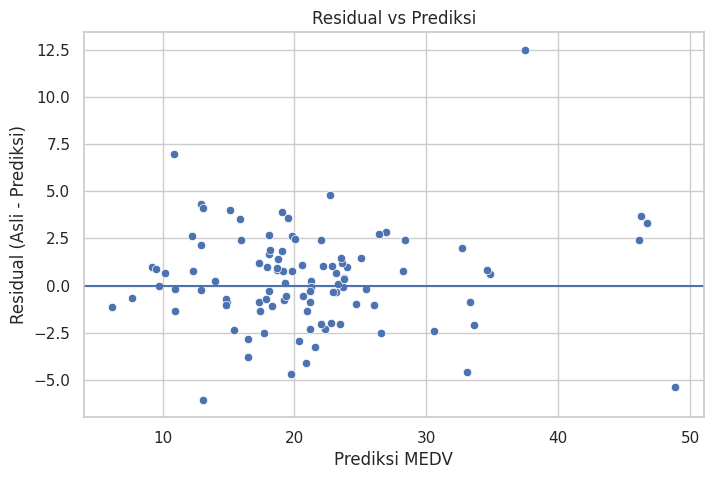

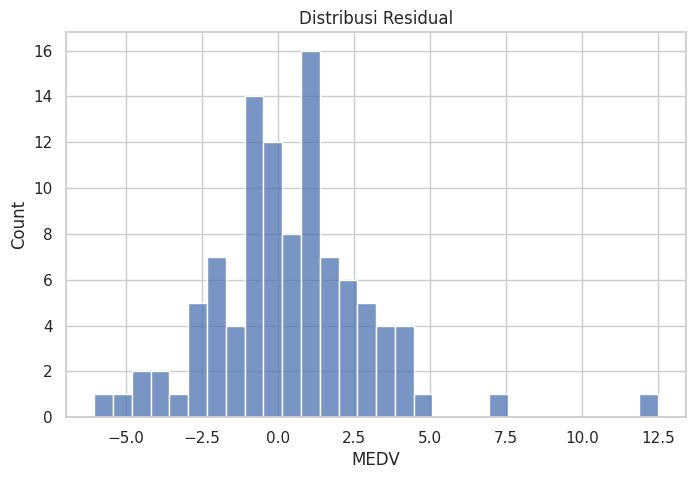

In [14]:
residual = target_uji - pred_uji

sns.scatterplot(x=pred_uji, y=residual)
plt.axhline(0)
plt.title("Residual vs Prediksi")
plt.xlabel("Prediksi MEDV")
plt.ylabel("Residual (Asli - Prediksi)")
plt.show()

sns.histplot(residual, bins=30)
plt.title("Distribusi Residual")
plt.show()


In [15]:
nama_file_model = "best_model.pkl"
joblib.dump(model_terbaik, nama_file_model)

print(f"Model terbaik sudah disimpan: {nama_file_model}")


Model terbaik sudah disimpan: best_model.pkl


In [16]:
from google.colab import files
files.download("best_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import sklearn, joblib, numpy, sys
print("python:", sys.version)
print("sklearn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("numpy :", numpy.__version__)


python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
sklearn: 1.6.1
joblib: 1.5.3
numpy : 2.0.2
